In [30]:
# Nettoyage complet
print("Nettoyage...")
%reset -f

%whos

Nettoyage...
Interactive namespace is empty.


In [31]:
import numpy.random as rd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sqlalchemy import text
import sqlalchemy
import gc
import pyodbc
from datetime import datetime
from pandas import NaT
import math
from scipy.stats import expon
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import time
from scipy.stats import gaussian_kde
import pickle

**On commence par charger les données de base de LogiPro**

In [32]:
# Connexion pyodbc à SQL Server

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.33;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

In [33]:
# Les requêtes : 

requete_lots_infos_basiques = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    l.lot_date_creation,
    l.lot_date_archive,
    l.lot_surface,
    l.lot_batiment,
    l.etage_id,
    l.adresse_id,
    o.negociateur_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_offre o ON o.offre_id = tj.offre_id
WHERE l.lot_actif = 1
"""

requete_lots_loyer = """
SELECT 
    tj.lot_id,
    tj.ol_actif,
    tj.offre_id,
    tj.ol_loyer
FROM dbo.tj_offre_lot tj
WHERE tj.ol_actif = 1
"""

requete_lots_adresses = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    a.adresse_id,
    a.adr_adresse,
    a.adr_adresse_cp,
    a.adr_adresse_ville,
    CAST(a.adr_plan_x AS FLOAT) AS adr_plan_x,
    CAST(a.adr_plan_y AS FLOAT) AS adr_plan_y,
    CAST(a.adr_geo_location AS VARCHAR(255)) AS adr_geo_location,
    a.code_insee_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_adresse a ON l.adresse_id = a.adresse_id
WHERE l.lot_actif = 1
"""

requete_lots_codes_insee = """
SELECT 
    tj.lot_id,
    ci.code_insee_id,
    ci.ci_code_postal,
    ci.ci_code_insee,
    ci.ci_ville
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_adresse a ON l.adresse_id = a.adresse_id
JOIN dbo.tr_code_insee ci ON a.code_insee_id = ci.code_insee_id
WHERE ci.pays_id = 28
"""

requete_demandes = """
SELECT
    demande_id,
    dem_actif,
    dem_surface_minimum,
    dem_surface_maximum,
    dem_budget_minimum,
    dem_budget_maximum,
    dem_recherche_cp,
    dem_date_creation,
    dem_date_archive
FROM dbo.t_demande
WHERE dem_actif = 1
"""

requete_duree_de_vie_negos = """
-- Requête qui permettra de trouver la distribution de la durée de vie empirique des négociateurs
-- ainsi que le processus suivi par leur date d'arrivée sur le marché.
-- Le groupe dans lequel ils arrivent, on s'en fiche comme la simulation doit se faire à l'échelle globale
-- A la limite, peut-être le faire entrer en jeu plus tard pcq le groupe d'appartenance peut avoir
-- une influence sur la durée de vie du négociateur

SELECT
    negociateur_id,
    neg_nom,
    neg_prenom,
    neg_date_creation,
    neg_date_archive,
    neg_actif
FROM dbo.t_negociateur
WHERE neg_actif = 1
"""

requete_gestion_de_lots_negociateurs = """
-- Requête comptage du nombre de lots qui ont été un jour en contact avec chaque négociateur
-- Pour trouver la distribution de l'"efficacité" des négociateurs

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    COUNT(DISTINCT tj.lot_id) AS nombre_lots_associes
FROM dbo.t_negociateur n
LEFT JOIN dbo.t_offre o
    ON o.negociateur_id = n.negociateur_id
LEFT JOIN dbo.tj_offre_lot tj
    ON tj.offre_id = o.offre_id
WHERE n.neg_actif = 1
GROUP BY
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif
HAVING COUNT(DISTINCT tj.lot_id) != 0
"""

requete_transactions_revenus_negociateurs = """ 
-- Maintenant, requête qui va chercher le nombre de transactions qu'ont fait chaque négociateur, 
-- et les revenus que ça a rapporté. Le but est de trouver leur spécialisation sur la base des recettes 
-- par transaction, mais aussi de comparer la quantité de lots avec lesquels ils ont été en contact
-- avec la quantité de transactions dans lesquelles ils vont être impliqués par la suite

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    n.groupe_id,
    n.agence_id,
    COUNT(t.transaction_id) AS nombre_transactions,
    SUM(t.tra_loyer) AS montant_total_transactions
FROM dbo.t_negociateur n
LEFT JOIN dbo.t_transaction t
    ON t.negociateur_id = n.negociateur_id
WHERE n.neg_actif = 1
GROUP BY
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    n.groupe_id,
    n.agence_id
HAVING COUNT(t.transaction_id) > 0
"""

requete_negociateurs_mandats = """ 
-- On relie maintenant les négociateurs à leurs mandats

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    m.mandat_id,
    m.mandat_type_id,
    m.man_date_creation,
    m.man_date_debut,
    m.man_date_fin,
    m.man_date_archive,
    m.man_actif
FROM dbo.t_negociateur n
LEFT JOIN dbo.t_mandat m
    ON m.negociateur_id = n.negociateur_id
WHERE m.man_actif = 1
"""

requete_agences_negociateurs = """ 
-- On relie les négociateurs à leurs agences respectives
-- Ce sera utile pour localiser les négociateurs et leur attribuer les lots qu'ils gèreront

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    
    a.agence_id,
    a.age_nom AS agence_nom,
    a.age_ville AS agence_ville,
    a.age_code_postal AS agence_code_postal,
    a.age_adresse as agence_adresse,
    a.age_actif

FROM dbo.t_negociateur n
LEFT JOIN dbo.t_agence a
    ON n.agence_id = a.agence_id
WHERE a.age_actif = 1
"""

# Ici on a remonté toutes les données actives dans LogiPro

In [34]:
lots_infos_basiques = pd.read_sql_query(requete_lots_infos_basiques, conn)
print(lots_infos_basiques.columns)

lots_loyers = pd.read_sql_query(requete_lots_loyer, conn)
print(lots_loyers.columns)

lots_codes_insee = pd.read_sql_query(requete_lots_codes_insee, conn)
print(lots_codes_insee.columns)

lots_adresses = pd.read_sql_query(requete_lots_adresses, conn)
print(lots_adresses.columns)

demandes = pd.read_sql_query(requete_demandes, conn)
print(demandes.columns)

duree_de_vie_negos = pd.read_sql_query(requete_duree_de_vie_negos, conn)
print(duree_de_vie_negos.columns)

gestion_de_lots_negociateurs = pd.read_sql_query(requete_gestion_de_lots_negociateurs, conn)
print(gestion_de_lots_negociateurs.columns)

transactions_revenus_negociateurs = pd.read_sql_query(requete_transactions_revenus_negociateurs, conn)
print(transactions_revenus_negociateurs.columns)

negociateurs_mandats = pd.read_sql_query(requete_negociateurs_mandats, conn)
print(negociateurs_mandats.columns)

agences_negociateurs = pd.read_sql_query(requete_agences_negociateurs, conn)
print(agences_negociateurs.columns)

C:\Users\quent\AppData\Local\Temp\ipykernel_184\4117252047.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_infos_basiques = pd.read_sql_query(requete_lots_infos_basiques, conn)


Index(['lot_id', 'lot_actif', 'lot_date_creation', 'lot_date_archive',
       'lot_surface', 'lot_batiment', 'etage_id', 'adresse_id',
       'negociateur_id'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_184\4117252047.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_loyers = pd.read_sql_query(requete_lots_loyer, conn)


Index(['lot_id', 'ol_actif', 'offre_id', 'ol_loyer'], dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_184\4117252047.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_codes_insee = pd.read_sql_query(requete_lots_codes_insee, conn)


...

Index(['negociateur_id', 'neg_nom', 'neg_prenom', 'neg_actif',
       'nombre_lots_associes'],
      dtype='object')
Index(['negociateur_id', 'neg_nom', 'neg_prenom', 'neg_actif', 'groupe_id',
       'agence_id', 'nombre_transactions', 'montant_total_transactions'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_184\4117252047.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions_revenus_negociateurs = pd.read_sql_query(requete_transactions_revenus_negociateurs, conn)
C:\Users\quent\AppData\Local\Temp\ipykernel_184\4117252047.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  negociateurs_mandats = pd.read_sql_query(requete_negociateurs_mandats, conn)


Index(['negociateur_id', 'neg_nom', 'neg_prenom', 'mandat_id',
       'mandat_type_id', 'man_date_creation', 'man_date_debut', 'man_date_fin',
       'man_date_archive', 'man_actif'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_184\4117252047.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  agences_negociateurs = pd.read_sql_query(requete_agences_negociateurs, conn)


Index(['negociateur_id', 'neg_nom', 'neg_prenom', 'neg_actif', 'agence_id',
       'agence_nom', 'agence_ville', 'agence_code_postal', 'agence_adresse',
       'age_actif'],
      dtype='object')


In [35]:
# On ferme la connexion à SQL Server

conn.commit()
cursor.close()
conn.close()

In [36]:
# Filtrer sur la France métropolitaine (en degrés WGS84)
lots_adresses = lots_adresses[
    (lots_adresses['adr_plan_x'] >= -5.0) & (lots_adresses['adr_plan_x'] <= 10.0) &  # longitudes
    (lots_adresses['adr_plan_y'] >= 41.0) & (lots_adresses['adr_plan_y'] <= 52.0)    # latitudes
].copy()

print(f"Nombre de lots après filtrage : {len(lots_adresses)}")

Nombre de lots après filtrage : 2297693


**On charge à présent les données calculées dans d'autres notebooks, généralement des distributions de probabilité estimées**

In [37]:
# Première chose à faire : on normalise la densité estimée des lots

gdf_offres = gpd.GeoDataFrame(lots_adresses, geometry=gpd.points_from_xy(lots_adresses.adr_plan_x, lots_adresses.adr_plan_y), crs="EPSG:4326")

# Reprojeter en Web Mercator 
gdf_offres = gdf_offres.to_crs(epsg=3857)

# Supprimer la colonne si elle existe déjà
if 'lot_actif' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif', inplace=True)
if 'lot_actif_x' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif_x', inplace=True)
if 'lot_actif_y' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif_y', inplace=True)

lots_actifs = lots_infos_basiques.groupby('lot_id', as_index=False)['lot_actif'].max()
gdf_offres = gdf_offres.merge(lots_actifs, on='lot_id', how='left')

# Filtrage : uniquement les points actifs
gdf_offres = gdf_offres[gdf_offres['lot_actif'] == 1]

gdf_offres = gdf_offres.to_crs(epsg=3857)

# On ne garde que ce qui est en France
gdf_offres = gdf_offres.cx[-560000:1200000, 5000000:6700000]

# Vérifier les min/max
print(gdf_offres['adr_plan_x'].min(), gdf_offres['adr_plan_x'].max())
print(gdf_offres['adr_plan_y'].min(), gdf_offres['adr_plan_y'].max())

# Vérifier les valeurs manquantes
print(gdf_offres[['adr_plan_x', 'adr_plan_y']].isnull().sum())

# Charger les régions métropolitaines
gdf_regions = gpd.read_file("https://france-geojson.gregoiredavid.fr/repo/regions.geojson")
codes_metropole = ['11', '24', '27', '28', '32', '44', '52', '53', '75', '76', '84', '93', '94']
gdf_regions = gdf_regions[gdf_regions['code'].isin(codes_metropole)].copy()

# Assurer la même projection
gdf_regions = gdf_regions.to_crs(epsg=3857)
gdf_offres = gdf_offres.to_crs(epsg=3857)

# Liste pour stocker les résultats
region_counts = []

# Boucler sur chaque région
for idx, region in gdf_regions.iterrows():
    region_name = region['nom']
    region_geom = region.geometry
    count = gdf_offres.geometry.within(region_geom).sum()
    region_counts.append({"region": region_name, "nombre_lots": count})

# Créer un DataFrame
df_lots_par_region = pd.DataFrame(region_counts).sort_values(by="region").reset_index(drop=True)

print(df_lots_par_region)

# Charger les données
kde_france = pd.read_parquet("kde_france_metropole.parquet", engine="fastparquet")

# Boucle manuelle pour multiplier par le nombre de lots de chaque région
for i, row in df_lots_par_region.iterrows() :
    region = row["region"]
    nb_lots = row["nombre_lots"]
    
    mask = kde_france["region"] == region
    kde_france.loc[mask, "density"] = kde_france.loc[mask, "density"] * nb_lots

kde_france["density"] = (kde_france["density"] / (df_lots_par_region["nombre_lots"].sum()))*1000000

print(kde_france["density"].sum())

-4.77380330000005 9.448236465454102
41.39147524875518 51.2312752
adr_plan_x    0
adr_plan_y    0
dtype: int64
                        region  nombre_lots
0         Auvergne-Rhône-Alpes       307732
1      Bourgogne-Franche-Comté         2419
2                     Bretagne         9504
3          Centre-Val de Loire        12980
4                        Corse           12
5                    Grand Est        29719
6              Hauts-de-France       106053
7                    Normandie        15147
8           Nouvelle-Aquitaine        73716
9                    Occitanie        56570
10            Pays de la Loire        27570
11  Provence-Alpes-Côte d'Azur        58374
12               Île-de-France      1596179
0.9999932210566791


<Axes: >

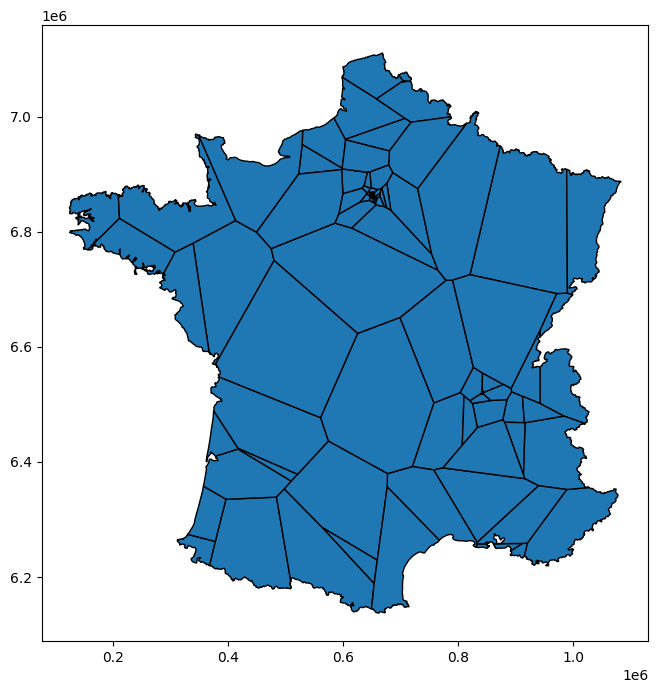

In [38]:
# Deuxième chose : on charge les régions de Voronoi des agences

gdf_agences_polygones = gpd.read_file("gdf_agences_polygones.geojson")
gdf_agences_polygones.plot(edgecolor="black", figsize=(8, 8))

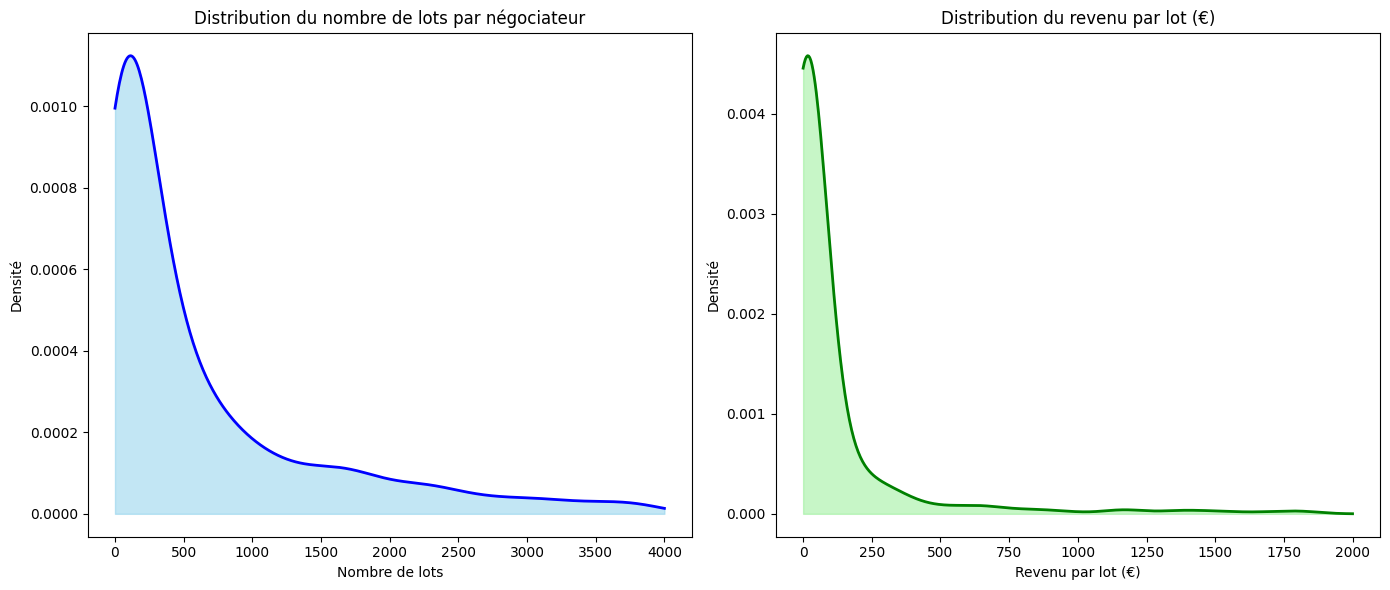

In [39]:
# On ouvre maintenant les distributions du nombre de lots gérés par négociateur et du revenu moyen par
# transaction par négociateur : 

with open("kde_nb_lots_negos.pkl", "rb") as f:
    kde_nb_lots_negos = pickle.load(f)

with open("kde_revenus_par_lot.pkl", "rb") as f:
    kde_revenus_par_lot = pickle.load(f)

# Définir les plages de valeurs pour chaque distribution
x_lots = np.linspace(0, 4000, 500)      # pour le nombre de lots par négociateur
x_revenus = np.linspace(0, 2000, 500)   # pour le revenu par lot (€)

# Évaluer les densités
y_lots = kde_nb_lots_negos.evaluate(x_lots)
y_revenus = kde_revenus_par_lot.evaluate(x_revenus)

# Créer les graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Distribution du nombre de lots par négociateur
axes[0].plot(x_lots, y_lots, color='blue', lw=2)
axes[0].fill_between(x_lots, y_lots, color='skyblue', alpha=0.5)
axes[0].set_title("Distribution du nombre de lots par négociateur")
axes[0].set_xlabel("Nombre de lots")
axes[0].set_ylabel("Densité")

# 2. Distribution du revenu par lot
axes[1].plot(x_revenus, y_revenus, color='green', lw=2)
axes[1].fill_between(x_revenus, y_revenus, color='lightgreen', alpha=0.5)
axes[1].set_title("Distribution du revenu par lot (€)")
axes[1].set_xlabel("Revenu par lot (€)")
axes[1].set_ylabel("Densité")

plt.tight_layout()
plt.show()

**Maintenant, on génère les données selon ces lois. On ira piocher dedans au cours de la simulation quand on en aura besoin**

Nombre de valeurs générées pour les lots : 2000
Nombre de valeurs générées pour les revenus : 2000


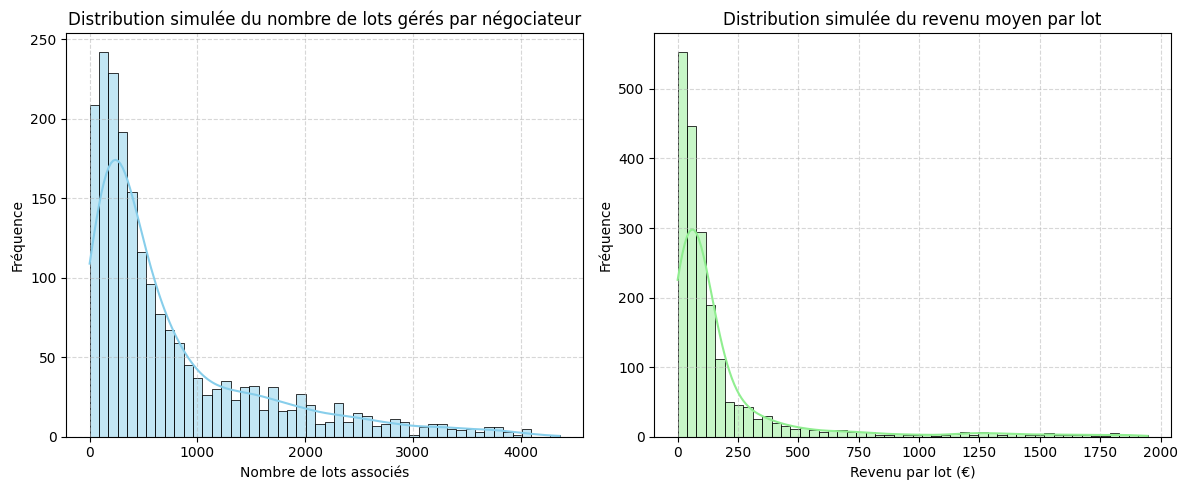

In [40]:
# On tire plus de points que nécessaires car certains tomberont dans le négatif
# (parce que la distribution kde estimée est un mélange gaussien, et déborde donc dans les négatifs...)
simulation_nb_lots_negos = np.floor(kde_nb_lots_negos.resample(6000)[0]).astype(int)
simulation_revenus_par_lot = kde_revenus_par_lot.resample(8000)[0]

# Filtration les valeurs aberrantes (négatives) on n'en garde que 2000 ça suffit
simulation_nb_lots_negos = [x for x in simulation_nb_lots_negos if x > 0]
simulation_nb_lots_negos = simulation_nb_lots_negos[:2000]
simulation_revenus_par_lot = [x for x in simulation_revenus_par_lot if x > 0]
simulation_revenus_par_lot = simulation_revenus_par_lot[:2000]

# Vérification qu'on ait bien généré assez de données avant de filtrer sur les positives
print(f"Nombre de valeurs générées pour les lots : {len(simulation_nb_lots_negos)}")
print(f"Nombre de valeurs générées pour les revenus : {len(simulation_revenus_par_lot)}")

# Visualisation
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(simulation_nb_lots_negos, bins=50, color='skyblue', kde=True)
plt.title("Distribution simulée du nombre de lots gérés par négociateur")
plt.xlabel("Nombre de lots associés")
plt.ylabel("Fréquence")
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
sns.histplot(simulation_revenus_par_lot, bins=50, color='lightgreen', kde=True)
plt.title("Distribution simulée du revenu moyen par lot")
plt.xlabel("Revenu par lot (€)")
plt.ylabel("Fréquence")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

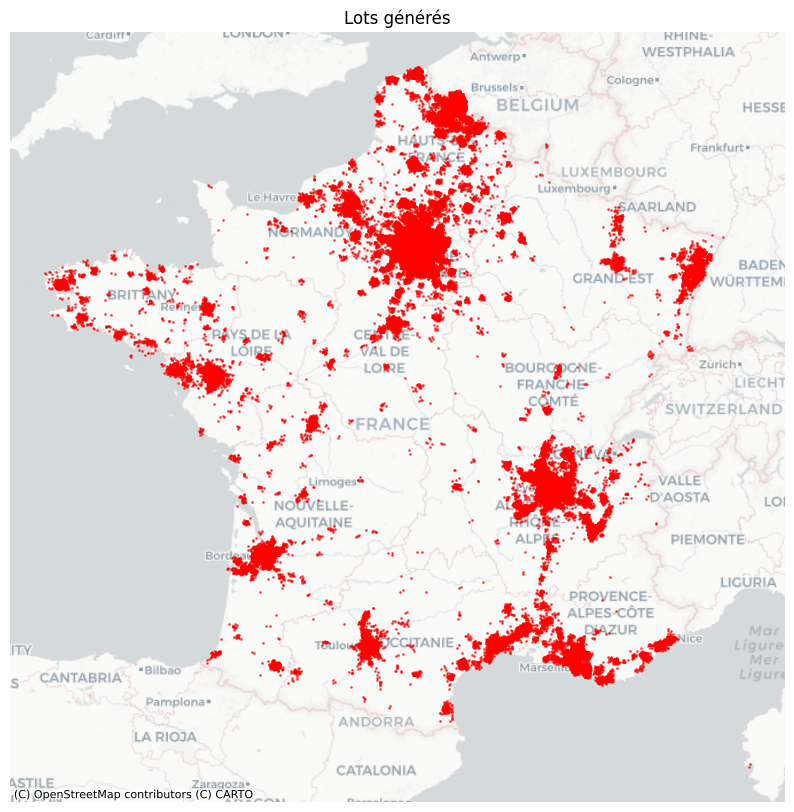

In [41]:
# Normalisation de la densité (au cas où la somme ne serait pas exactement 1)
kde_france["density"] = kde_france["density"] / kde_france["density"].sum()

# Nombre total de points à générer
n_points = 500000

# Tirage aléatoire de la maille du quadrillage dans laquelle on va mettre le nouveau lot
indices = np.random.choice(
    kde_france.index,
    size=n_points,
    replace=True,
    p=kde_france["density"].values
)

# Récupération des coordonnées des points
sampled_points = kde_france.loc[indices, ["x", "y"]].values

# On convertit en gdf
gdf_simulation_lieux_lots = gpd.GeoDataFrame(
    geometry=[Point(xy) for xy in sampled_points],
    crs="EPSG:3857"
)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_simulation_lieux_lots.plot(ax=ax, markersize=1, color="red", alpha=0.6)

# On ajoute le fond de carte
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_axis_off()  # Pour enlever les axes 
plt.title("Lots générés")
plt.show()

In [42]:
# Ici on relie chaque lot simulé à l'agence qui s'en occupera

# On met dans le même système de projection
gdf_simulation_lieux_lots = gdf_simulation_lieux_lots.to_crs(epsg=2154)  # même CRS que tes polygones
gdf_agences_polygones = gdf_agences_polygones.to_crs(epsg=2154)

# On relie à la bonne agence en se basant sur la région de Voronoï à laquelle appartient le point
gdf_lots_agences = gpd.sjoin(
    gdf_simulation_lieux_lots,
    gdf_agences_polygones[['agence_id', 'geometry']],
    how='left',
    predicate='within'
)

print(gdf_lots_agences.head())
print(f"✅ {gdf_lots_agences['agence_id'].notna().sum():,} points ont été associés à une agence sur {len(gdf_lots_agences):,} au total")

nb_agences_uniques = gdf_lots_agences['agence_id'].nunique()
print(f"Nombre d'agences différentes dans le tableau : {nb_agences_uniques}")

                         geometry  index_right  agence_id
0   POINT (655952.66 6863745.873)         78.0      135.0
1  POINT (649375.069 6865113.562)         16.0      125.0
2  POINT (648733.763 6867089.546)         44.0      245.0
3   POINT (648039.88 6863154.378)         99.0      440.0
4  POINT (644035.261 6857932.363)         12.0      146.0
✅ 497,938 points ont été associés à une agence sur 500,000 au total
Nombre d'agences différentes dans le tableau : 103


✅ CRS des lots : EPSG:2154
✅ CRS des agences : EPSG:2154


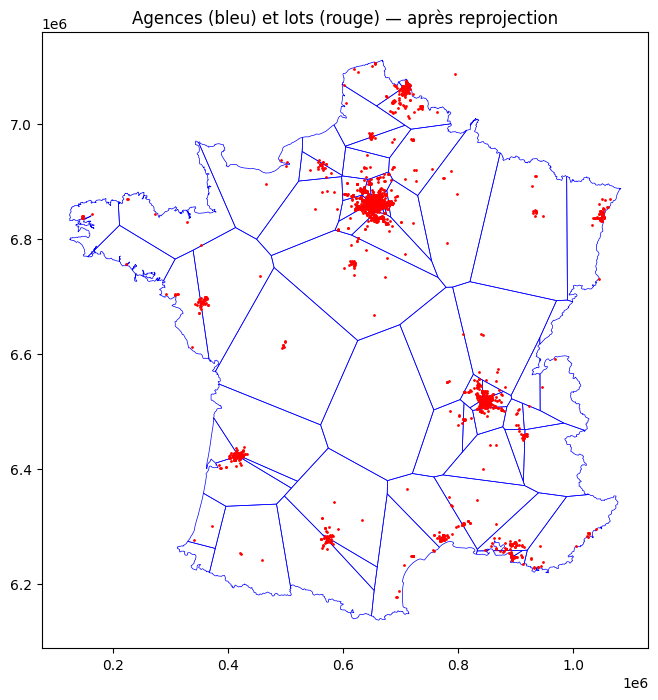

✅ 2,295,962 lots sur 2,297,693 ont été associés à une agence (99.92%).
     lot_id  agence_id
90     -370      370.0
312   10045      171.0
313   10167       76.0
334   10823      345.0
335   10824      345.0


In [43]:
# On formate ici le dataframe lots_agences pour pouvoir ensuite relier chaque lot à une agence

# Les coordonnées actuelles sont en degrés (WGS84)
gdf_lots = gpd.GeoDataFrame(
    lots_adresses.copy(),
    geometry=gpd.points_from_xy(lots_adresses["adr_plan_x"], lots_adresses["adr_plan_y"]),
    crs="EPSG:4326"  # système géographique
)

gdf_lots = gdf_lots.to_crs(epsg=2154)

print("✅ CRS des lots :", gdf_lots.crs)
print("✅ CRS des agences :", gdf_agences_polygones.crs)

fig, ax = plt.subplots(figsize=(8, 8))
gdf_agences_polygones.plot(ax=ax, color='none', edgecolor='blue', linewidth=0.5)
gdf_lots.sample(5000).plot(ax=ax, color='red', markersize=1)
plt.title("Agences (bleu) et lots (rouge) — après reprojection")
plt.show()

gdf_lots_agences = gpd.sjoin(
    gdf_lots,
    gdf_agences_polygones[['agence_id', 'geometry']],
    how="left",
    predicate="within"
)

nb_associes = gdf_lots_agences['agence_id'].notna().sum()
total_lots = len(gdf_lots_agences)
print(f"✅ {nb_associes:,} lots sur {total_lots:,} ont été associés à une agence ({nb_associes/total_lots:.2%}).")

lots_agences = gdf_lots_agences[['lot_id', 'agence_id']].copy()
print(lots_agences.head())

✅ 2,295,962 lots sur 2,297,693 ont été associés à une agence (99.92%).
Tableau provisoire (reste à ajouter le négociateur) :
     lot_id  agence_id
90     -370      370.0
312   10045      171.0
313   10167       76.0
334   10823      345.0
335   10824      345.0


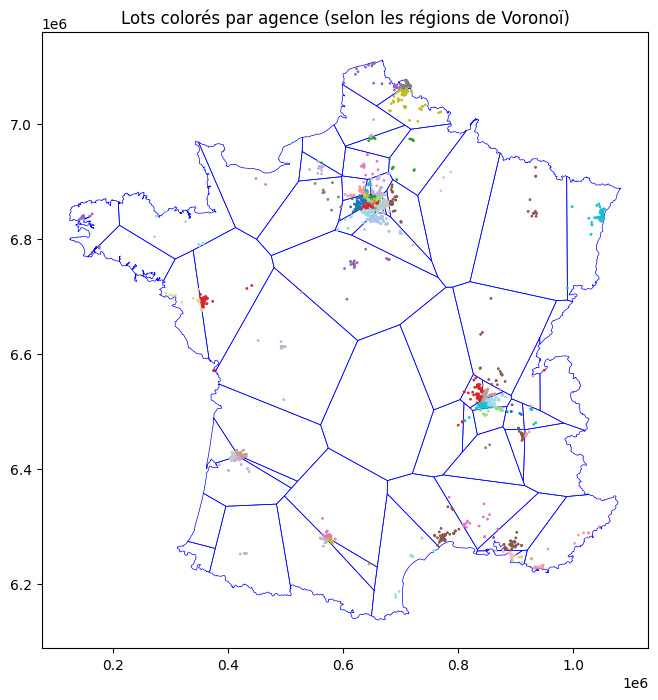

In [44]:
# On associe maintenant chaque lot à la région de Voronoï de son agence

gdf_lots_agences = gpd.sjoin(
    gdf_lots,
    gdf_agences_polygones[['agence_id', 'geometry']],
    how="left",
    predicate="within"
)

nb_associes = gdf_lots_agences['agence_id'].notna().sum()
total_lots = len(gdf_lots_agences)
print(f"✅ {nb_associes:,} lots sur {total_lots:,} ont été associés à une agence ({nb_associes/total_lots:.2%}).")

lots_agences = gdf_lots_agences[['lot_id', 'agence_id']].copy()

print("Tableau provisoire (reste à ajouter le négociateur) :")
print(lots_agences.head())

# On voit ce que ca donne visuellement
fig, ax = plt.subplots(figsize=(8, 8))
gdf_agences_polygones.plot(ax=ax, color='none', edgecolor='blue', linewidth=0.5)
gdf_lots_agences.sample(5000).plot(ax=ax, column='agence_id', markersize=1, cmap='tab20', legend=False)
plt.title("Lots colorés par agence (selon les régions de Voronoï)")
plt.show()

In [45]:
# === Fusion de lots_adresses (avec agence_id) et lots_infos_basiques (avec negociateur_id)
lots_agences = lots_agences.merge(
    lots_infos_basiques[['lot_id', 'negociateur_id']],
    on='lot_id',
    how='left'
)

# === Vérification rapide
print("✅ Fusion terminée !")
print("Nombre de lignes :", len(lots_agences))
print("Nombre de lots avec un négociateur associé :", lots_agences['negociateur_id'].notna().sum())
print(lots_agences.head())

✅ Fusion terminée !
Nombre de lignes : 3754009
Nombre de lots avec un négociateur associé : 3754009
   lot_id  agence_id  negociateur_id
0    -370      370.0               0
1   10045      171.0              91
2   10167       76.0              88
3   10823      345.0              86
4   10824      345.0              86


**VISUALISATION DES DATAFRAMES A UTILISER**

In [46]:
print(lots_agences)

          lot_id  agence_id  negociateur_id
0           -370      370.0               0
1          10045      171.0              91
2          10167       76.0              88
3          10823      345.0              86
4          10824      345.0              86
...          ...        ...             ...
3754004  4873528      215.0            5334
3754005  4873529      378.0            2631
3754006  4873542      428.0            4361
3754007  4873543      463.0            4361
3754008  4873544       25.0            4713

[3754009 rows x 3 columns]


In [47]:
print(kde_france)

                    x             y        density         region
0        1.611110e+05  6.127209e+06  5.674532e-123  Île-de-France
1        1.621110e+05  6.127209e+06  1.811746e-120  Île-de-France
2        1.631110e+05  6.127209e+06  1.395926e-117  Île-de-France
3        1.641110e+05  6.127209e+06  9.627551e-115  Île-de-France
4        1.651110e+05  6.127209e+06  5.989782e-112  Île-de-France
...               ...           ...            ...            ...
2138641  1.060680e+06  5.313909e+06   2.072215e-63          Corse
2138642  1.061680e+06  5.313909e+06   7.063852e-64          Corse
2138643  1.062680e+06  5.313909e+06   2.156508e-64          Corse
2138644  1.063680e+06  5.313909e+06   5.896094e-65          Corse
2138645  1.064680e+06  5.313909e+06   1.443717e-65          Corse

[2138646 rows x 4 columns]


In [48]:
print(gdf_agences_polygones)

     agence_id                        agence_nom  nb_transactions  \
0            8  CONSEILS & SERVICES  IMMOBILIERS               26   
1           16                            PERIAL                0   
2           19                       ALEX BOLTON            26066   
3           23                             PRIMM                9   
4           25             ARTHUR LOYD IDF OUEST             2923   
..         ...                               ...              ...   
101        441              EVOLIS LYON ACTIVITE               12   
102        449          EVOLIS ILE DE FRANCE EST               28   
103        460          EVOLIS ILE DE FRANCE SUD                0   
104        463       BMR Immobilier d’entreprise                0   
105        468                OCTOPUS IMMOBILIER                0   

                                              geometry  
0    POLYGON ((629657.96 6851437.473, 592285.118 68...  
1    POLYGON ((649274.001 6864785.507, 648208.7 686...  


In [49]:
print(kde_nb_lots_negos)

In [50]:
print(kde_revenus_par_lot)

**DEFINITION DES FONCTIONS QUI GENERERONT LES DONNEES**

In [51]:
def lots_random() :
    simulation_nb_lots_negos = np.floor(kde_nb_lots_negos.resample(6000)[0]).astype(int)
    
# On tire plus de points que nécessaires car certains tomberont dans le négatif
# (parce que la distribution kde estimée est un mélange gaussien, et déborde donc dans les négatifs...)
simulation_nb_lots_negos = np.floor(kde_nb_lots_negos.resample(6000)[0]).astype(int)
simulation_revenus_par_lot = kde_revenus_par_lot.resample(8000)[0]

# Filtration les valeurs aberrantes (négatives) on n'en garde que 2000 ça suffit
simulation_nb_lots_negos = [x for x in simulation_nb_lots_negos if x > 0]
simulation_nb_lots_negos = simulation_nb_lots_negos[:2000]
simulation_revenus_par_lot = [x for x in simulation_revenus_par_lot if x > 0]
simulation_revenus_par_lot = simulation_revenus_par_lot[:2000]

# Vérification qu'on ait bien généré assez de données avant de filtrer sur les positives
print(f"Nombre de valeurs générées pour les lots : {len(simulation_nb_lots_negos)}")
print(f"Nombre de valeurs générées pour les revenus : {len(simulation_revenus_par_lot)}")

Nombre de valeurs générées pour les lots : 2000
Nombre de valeurs générées pour les revenus : 2000


In [ ]:
def negociateurs_random() :

SyntaxError: incomplete input (3056606688.py, line 1)

In [ ]:
def transactions_random() :

**BOUCLE FINALE POUR LA SIMULATION DE MONTE CARLO**

In [ ]:
nb_iterations = 100

In [ ]:
for i in range(nb_iterations) :

    # On initialise les listes contenant les nouveautés
    nouveaux_negos = []
    agences_nouveaux_negos = [] # On relie les nouveaux négos à une agence
    nouvelles_offres = []
    
    # On génère les données de ce qui va possiblement se passer sur le marché en fonction des distributions
    # estimées précédemment
    lots_simules = lots_random()
    negociateurs_simules = negociateurs_random()
    transactions_simulees = transactions_random()
    
    # On va boucler sur 365 périodes, soit un an
    for periode_actuelle in range(365) :


In [ ]:
# Schéma : 

# On itère autant de fois qu'il faut
    # On boucle sur l'annee
        # On genere les nouvelles offres
        # On teste si il y a besoin d'un nouveau négociateur
            # Si oui    
                # On simule si il va se créer une agence ou si il va en rejoindre une existante
                # On lui attribue les lots en trop
            # Si non
                # On attribue les lots aux négociateurs existants
        # On genere les nouvelles transactions
        # On supprime les offres trop vieilles et les offres qui fait l'objet d'une transaction
        # On teste s'il y a trop de négociateurs par rapport aux offres
            # Si oui, celui qui se trouve être le plus loin de son type quitte le marché
            # Si non, on garde comme c'est